# Strobl JEPA evaluation

Evaluate the trained latent dynamics model on the full Strobl controlled-tumor benchmark.

This notebook checks:

1. training and validation behavior;
2. held-out spatial architectures;
3. latent diversity and macrostate readability;
4. free-running latent and count predictions;
5. learned dose direction against paired ABM trajectories; and
6. the expected ABM–ODE discrepancy caused by spatial structure.

In [ ]:
from pathlib import Path
import csv
import json

import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import torch

from jepa_control.evaluate import (
    encode_all,
    fit_readout,
    horizon_errors,
    latent_pca,
    latent_rollout_batch,
    load_model,
    load_split_trajectories,
    readout_predict,
    readout_r2,
)
from koopman_control.paths import strobl_dataset_path

DATASET = strobl_dataset_path("full")
RUN_DIR = Path("../outputs/jepa_training/jepa-strobl-h30-spatial-v2")
if not RUN_DIR.exists():
    RUN_DIR = Path("outputs/jepa_training/jepa-strobl-full-h20-mlp-valloss-e50")
CHECKPOINTS = sorted((RUN_DIR / "checkpoints").glob("best-*.ckpt"))
if not DATASET.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET}")
if not CHECKPOINTS:
    raise FileNotFoundError(f"No best checkpoint found under {RUN_DIR}")
CHECKPOINT = CHECKPOINTS[-1]

print(f"Dataset:   {DATASET}")
print(f"Run:       {RUN_DIR.resolve()}")
print(f"Checkpoint:{CHECKPOINT.resolve()}")
print(f"Device:    {'mps' if torch.backends.mps.is_available() else 'cpu'}")

Dataset:   /Users/jacobevarts/BagheriLab/abm-control/data/strobl/full/dataset.h5
Run:       /Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-strobl-full-h20-mlp-valloss-e50
Checkpoint:/Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-strobl-full-h20-mlp-valloss-e50/checkpoints/best-047-3648-0.281677.ckpt
Device:    mps


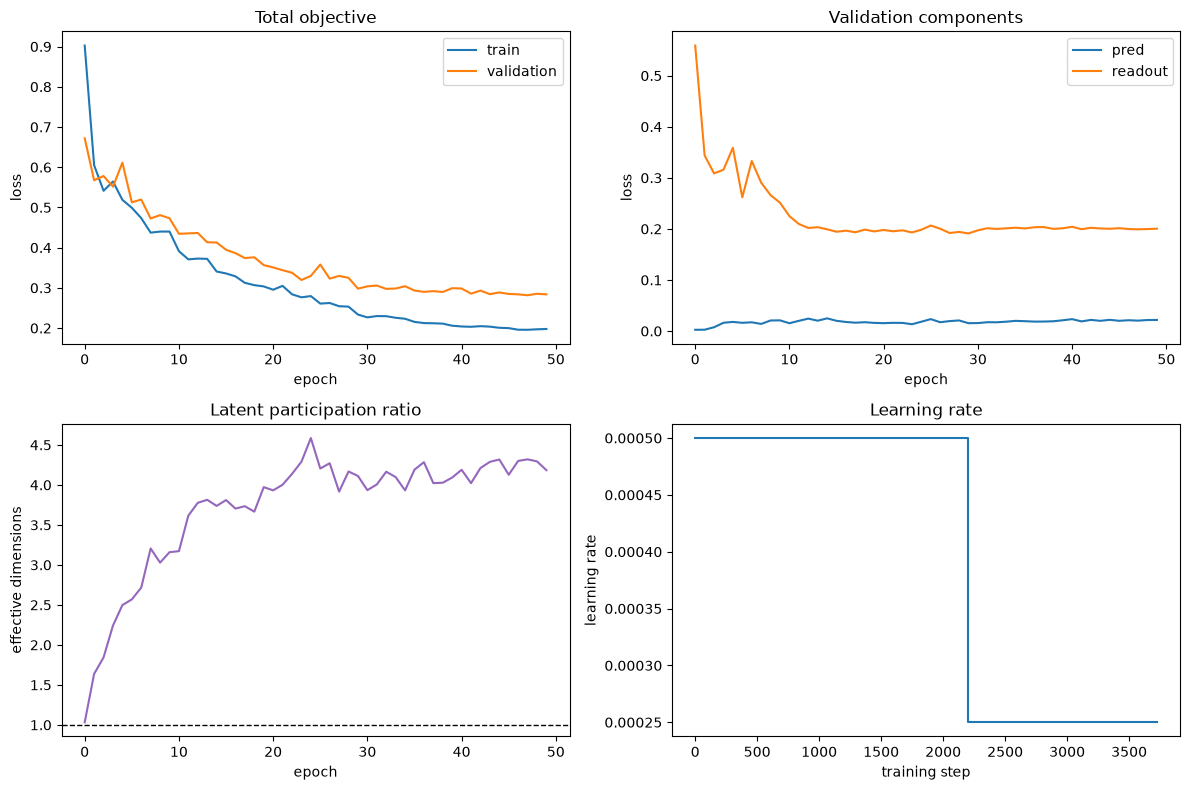

{
  "run_dir": "/Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-strobl-full-h20-mlp-valloss-e50",
  "best_checkpoint": "/Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-strobl-full-h20-mlp-valloss-e50/checkpoints/best-047-3648-0.281677.ckpt",
  "best_val_loss": 0.28167709708213806,
  "best_epoch": 47,
  "best_step": 3648,
  "stopped_epoch": 50,
  "stop_reason": "max_epochs",
  "duration_seconds": 508.7358328749833,
  "test_metrics": {
    "test_loss": 0.5626630783081055,
    "test_pred": 0.021354032680392265,
    "test_vic_var": 0.26557594537734985,
    "test_vic_cov": 1.6426030397415161,
    "test_readout": 0.6876466274261475
  }
}


In [12]:
# Training history
with (RUN_DIR / "logs" / "metrics.csv").open() as handle:
    rows = list(csv.DictReader(handle))


def series(name, x_name="epoch"):
    points = []
    for row in rows:
        if row.get(x_name) and row.get(name):
            points.append((int(row[x_name]), float(row[name])))
    return np.asarray(points, dtype=float)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for name, label in (("train_loss", "train"), ("val_loss", "validation")):
    values = series(name)
    axes[0, 0].plot(values[:, 0], values[:, 1], label=label)
axes[0, 0].set(title="Total objective", xlabel="epoch", ylabel="loss")
axes[0, 0].legend()

for name in ("val_pred", "val_readout"):
    values = series(name)
    axes[0, 1].plot(values[:, 0], values[:, 1], label=name.removeprefix("val_"))
axes[0, 1].set(title="Validation components", xlabel="epoch", ylabel="loss")
axes[0, 1].legend()

pr = series("participation_ratio")
axes[1, 0].plot(pr[:, 0], pr[:, 1], color="tab:purple")
axes[1, 0].axhline(1, color="black", ls="--", lw=1)
axes[1, 0].set(title="Latent participation ratio", xlabel="epoch", ylabel="effective dimensions")

lr = series("lr-AdamW", "step")
axes[1, 1].step(lr[:, 0], lr[:, 1], where="post")
axes[1, 1].set(title="Learning rate", xlabel="training step", ylabel="learning rate")

fig.tight_layout()
plt.show()

result = json.loads((RUN_DIR / "result.json").read_text())
print(json.dumps(result, indent=2))

In [13]:
# Load the checkpoint and deterministic trajectory subsets.
# Keep the model on CPU because the reusable evaluation helpers construct CPU tensors.
model = load_model(CHECKPOINT)
model.eval()

train_trajs = load_split_trajectories(DATASET, "train", max_runs=16, seed=17)
test_trajs = load_split_trajectories(DATASET, "test", max_runs=20, seed=23)
controlled_trajs = load_split_trajectories(
    DATASET,
    "test",
    where={"subset": "controlled_evaluation"},
)

print("Model horizon:", model.hparams.horizon)
print("Predictor:", model.hparams.predictor)
print("Latent width:", model.latent_dim)
print("Trajectory counts:", {
    "readout_train": len(train_trajs),
    "held_out_test": len(test_trajs),
    "paired_control": len(controlled_trajs),
})

train_enc = encode_all(model, train_trajs)
test_enc = encode_all(model, test_trajs)
controlled_enc = encode_all(model, controlled_trajs)
print("Encoded shapes:", train_enc["z"].shape, test_enc["z"].shape, controlled_enc["z"].shape)

Model horizon: 20
Predictor: residual_mlp
Latent width: 16
Trajectory counts: {'readout_train': 16, 'held_out_test': 20, 'paired_control': 30}
Encoded shapes: (16, 151, 16) (20, 163, 16) (30, 501, 16)


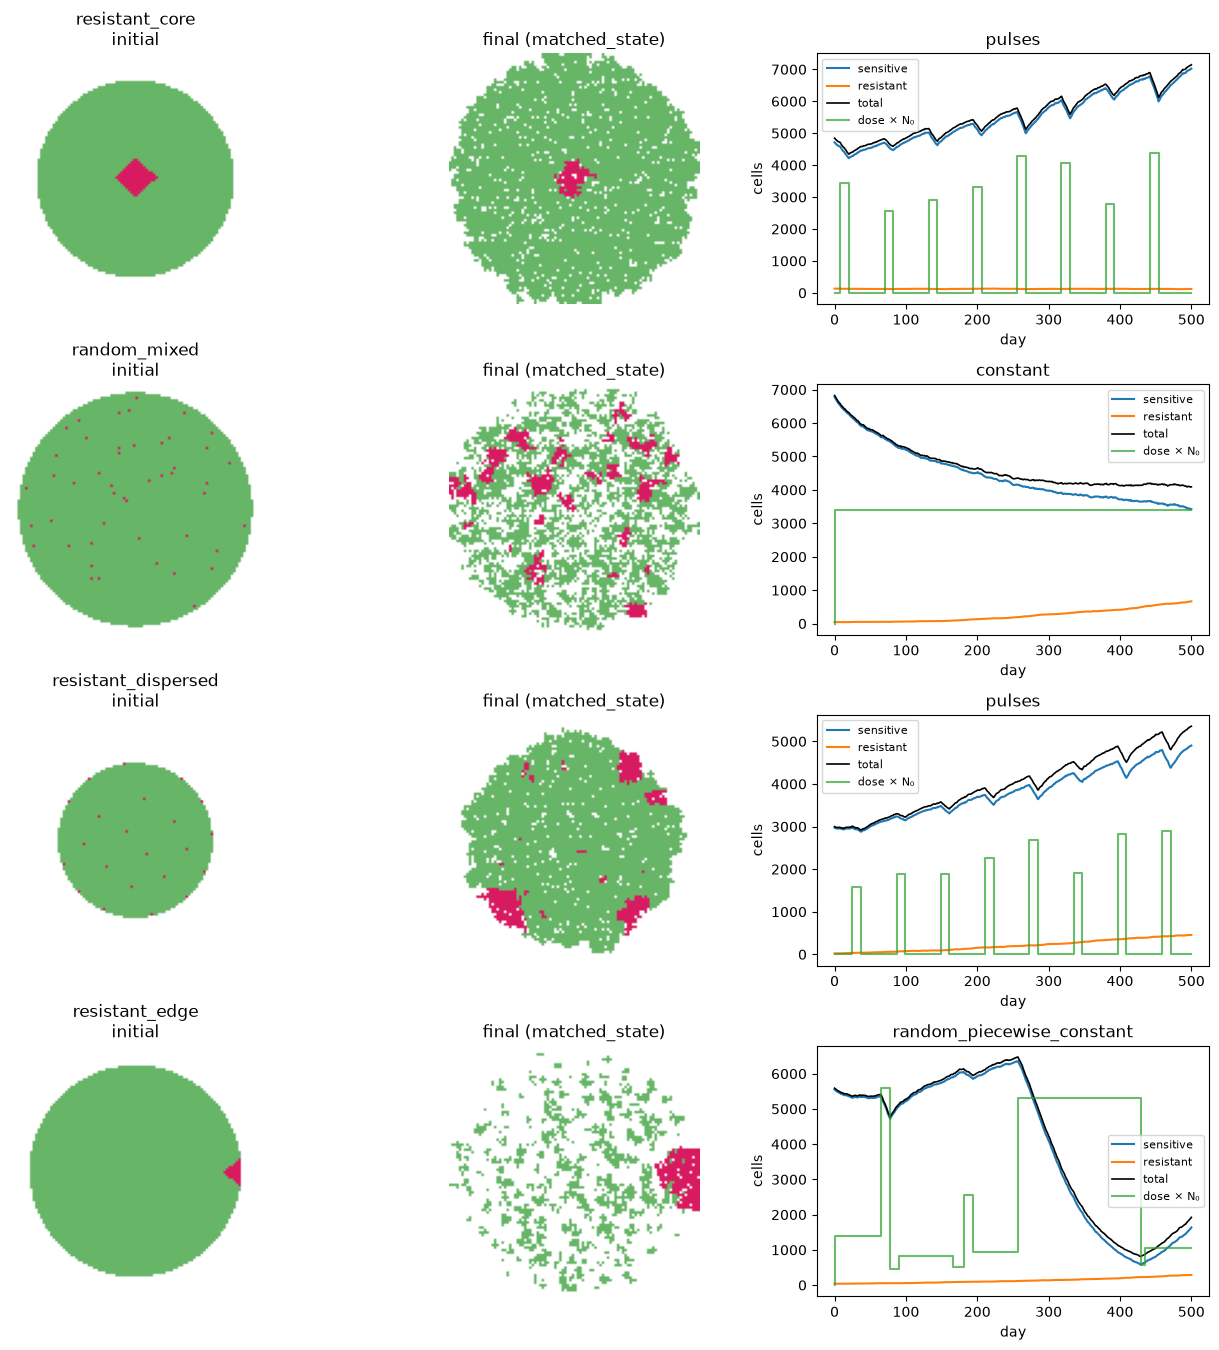

In [14]:
# Representative held-out spatial trajectories
cmap = ListedColormap(("white", "#67b567", "#d81b60"))
selected = []
seen = set()
for trajectory in test_trajs:
    key = (trajectory.get("architecture"), trajectory.get("subset"))
    if key not in seen:
        selected.append(trajectory)
        seen.add(key)
    if len(selected) == 4:
        break

fig, axes = plt.subplots(len(selected), 3, figsize=(13, 3.4 * len(selected)), squeeze=False)
for row, trajectory in enumerate(selected):
    grid = np.argmax(trajectory["frames"], axis=1)
    obs = trajectory["obs"]
    action = trajectory["controls"]
    axes[row, 0].imshow(grid[0], cmap=cmap, vmin=0, vmax=2)
    axes[row, 0].set_title(f"{trajectory.get('architecture')}\ninitial")
    axes[row, 1].imshow(grid[-1], cmap=cmap, vmin=0, vmax=2)
    axes[row, 1].set_title(f"final ({trajectory.get('subset')})")
    axes[row, 2].plot(obs[:, 0], label="sensitive")
    axes[row, 2].plot(obs[:, 1], label="resistant")
    axes[row, 2].plot(obs[:, 2], label="total", color="black", lw=1.2)
    axes[row, 2].step(np.arange(len(action)), action * obs[0, 2], label="dose × N₀", alpha=0.7)
    axes[row, 2].set(title=trajectory.get("policy"), xlabel="day", ylabel="cells")
    axes[row, 2].legend(fontsize=8)
    for col in (0, 1):
        axes[row, col].axis("off")
fig.tight_layout()
plt.show()

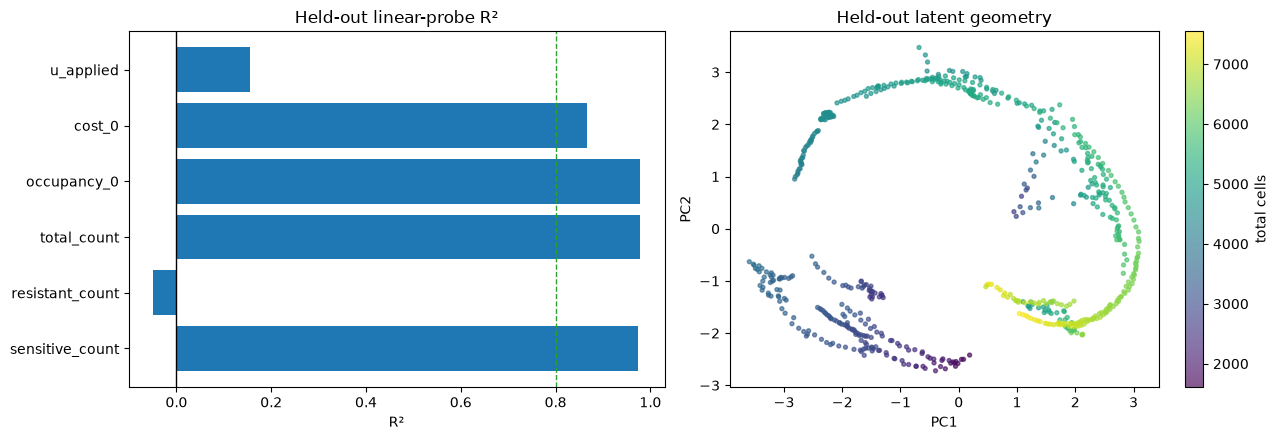

Participation ratio: 4.348
PCs needed for 95% variance: 6
Held-out R²: {'sensitive_count': np.float64(0.973), 'resistant_count': np.float64(-0.049), 'total_count': np.float64(0.979), 'occupancy_0': np.float64(0.979), 'cost_0': np.float64(0.866), 'u_applied': 0.155}


In [15]:
# Latent geometry, macrostate readability, and actuator signature
readout = fit_readout(train_enc, ridge=1.0)
macro_r2 = readout_r2(readout, test_enc)
pca = latent_pca(test_enc)


def scalar_probe_r2(train, test, target):
    x_train = train["z"].reshape(-1, train["z"].shape[-1])
    x_test = test["z"].reshape(-1, test["z"].shape[-1])
    y_train = target(train).reshape(-1)
    y_test = target(test).reshape(-1)
    mu, sd = x_train.mean(0), x_train.std(0) + 1e-8
    design = np.c_[(x_train - mu) / sd, np.ones(len(x_train))]
    theta = np.linalg.solve(design.T @ design + 1e-3 * np.eye(design.shape[1]), design.T @ y_train)
    prediction = np.c_[(x_test - mu) / sd, np.ones(len(x_test))] @ theta
    return 1 - np.sum((y_test - prediction) ** 2) / max(np.sum((y_test - y_test.mean()) ** 2), 1e-12)


u_r2 = scalar_probe_r2(train_enc, test_enc, lambda encoded: encoded["controls"])
metrics = {**macro_r2, "u_applied": float(u_r2)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(list(metrics), list(metrics.values()))
axes[0].axvline(0, color="black", lw=1)
axes[0].axvline(0.8, color="tab:green", ls="--", lw=1)
axes[0].set(title="Held-out linear-probe R²", xlabel="R²")

coords = pca["coords"].reshape(-1, model.latent_dim)
total = test_enc["obs"][..., test_enc["obs_names"].index("total_count")].reshape(-1)
points = np.arange(0, len(coords), 5)
scatter = axes[1].scatter(coords[points, 0], coords[points, 1], c=total[points], s=8, cmap="viridis", alpha=0.65)
axes[1].set(title="Held-out latent geometry", xlabel="PC1", ylabel="PC2")
fig.colorbar(scatter, ax=axes[1], label="total cells")
fig.tight_layout()
plt.show()

print("Participation ratio:", round(pca["participation_ratio"], 3))
print("PCs needed for 95% variance:", pca["n95"])
print("Held-out R²:", {key: round(value, 3) for key, value in metrics.items()})

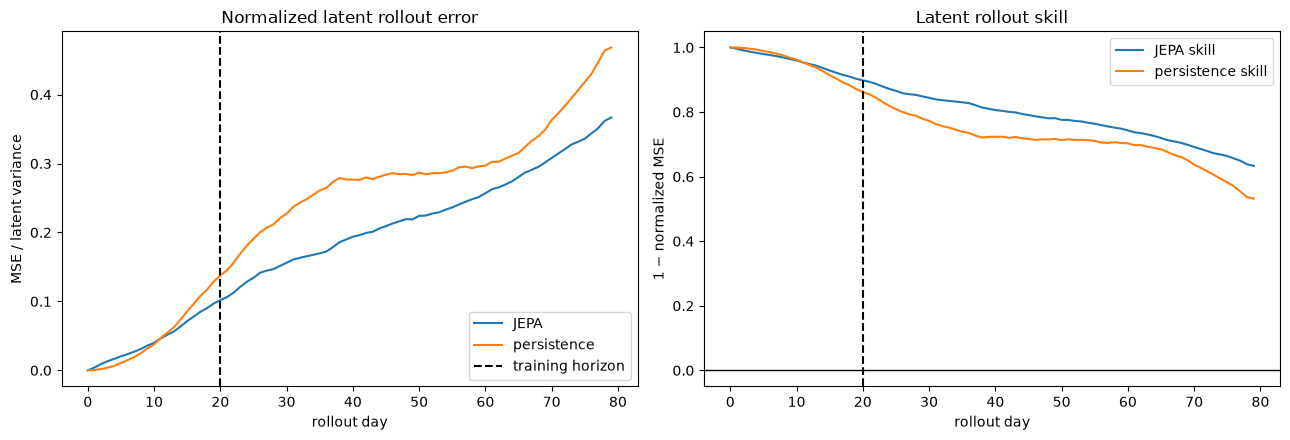

H= 1: JEPA skill=+0.996, persistence=+1.000
H= 5: JEPA skill=+0.980, persistence=+0.989
H=10: JEPA skill=+0.960, persistence=+0.962
H=20: JEPA skill=+0.898, persistence=+0.862
H=40: JEPA skill=+0.806, persistence=+0.723


In [16]:
# Free-running latent error versus a persistence baseline
show = min(80, test_enc["z"].shape[1])
rollout_enc = {
    **test_enc,
    "z": test_enc["z"][:, :show],
    "controls": test_enc["controls"][:, :show],
    "obs": test_enc["obs"][:, :show],
}
errors = horizon_errors(model, rollout_enc)
steps = errors["steps"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(steps[:show], errors["full"][:show] / errors["latent_var"], label="JEPA")
axes[0].plot(steps[:show], errors["persistence"][:show] / errors["latent_var"], label="persistence")
axes[0].axvline(model.hparams.horizon, color="black", ls="--", label="training horizon")
axes[0].set(title="Normalized latent rollout error", xlabel="rollout day", ylabel="MSE / latent variance")
axes[0].legend()

axes[1].plot(steps[:show], errors["skill_full"][:show], label="JEPA skill")
axes[1].plot(steps[:show], errors["skill_persistence"][:show], label="persistence skill")
axes[1].axhline(0, color="black", lw=1)
axes[1].axvline(model.hparams.horizon, color="black", ls="--")
axes[1].set(title="Latent rollout skill", xlabel="rollout day", ylabel="1 − normalized MSE")
axes[1].legend()
fig.tight_layout()
plt.show()

for horizon in (1, 5, 10, 20, 40):
    if horizon < len(steps):
        print(f"H={horizon:>2}: JEPA skill={errors['skill_full'][horizon]:+.3f}, persistence={errors['skill_persistence'][horizon]:+.3f}")

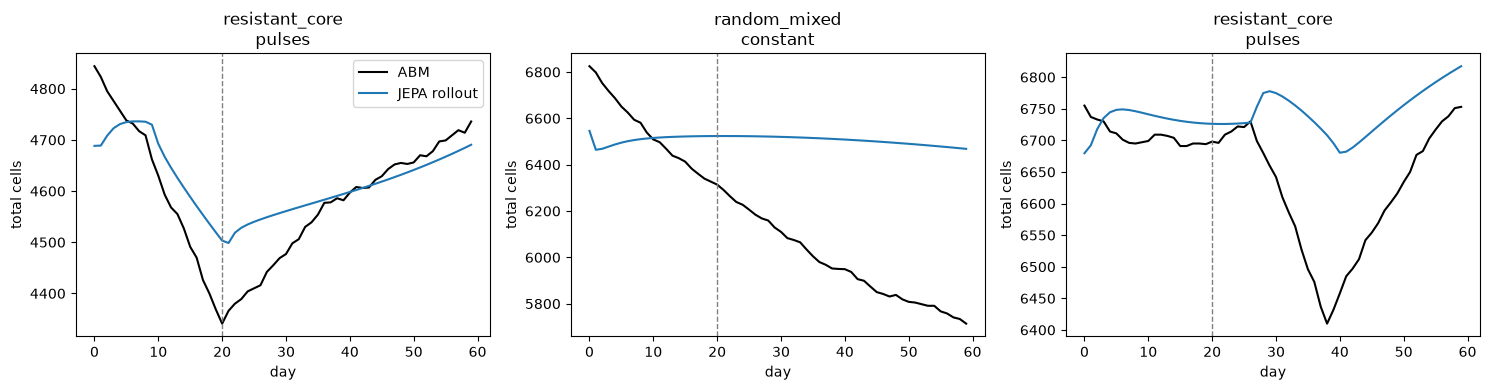

Total-count H=10: RMSE=279.9 cells, correlation=+0.984
Total-count H=20: RMSE=423.5 cells, correlation=+0.952
Total-count H=40: RMSE=608.5 cells, correlation=+0.905


In [17]:
# Translate free latent rollouts back to cell counts with the post-hoc readout
total_readout_idx = readout["names"].index("total_count")
total_obs_idx = test_enc["obs_names"].index("total_count")
show = min(60, test_enc["z"].shape[1])
z_rollout = latent_rollout_batch(
    model,
    test_enc["z"][:, 0],
    test_enc["controls"][:, :show],
)
predicted_obs = readout_predict(readout, z_rollout)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for index, ax in enumerate(axes):
    true = test_enc["obs"][index, :show, total_obs_idx]
    pred = predicted_obs[index, :show, total_readout_idx]
    meta = test_enc["meta"][index]
    ax.plot(true, label="ABM", color="black")
    ax.plot(pred, label="JEPA rollout", color="tab:blue")
    ax.axvline(model.hparams.horizon, color="gray", ls="--", lw=1)
    ax.set(title=f"{meta.get('architecture')}\n{meta.get('policy')}", xlabel="day", ylabel="total cells")
axes[0].legend()
fig.tight_layout()
plt.show()

for horizon in (10, 20, 40):
    if horizon < show:
        true = test_enc["obs"][:, horizon, total_obs_idx]
        pred = predicted_obs[:, horizon, total_readout_idx]
        rmse = np.sqrt(np.mean((true - pred) ** 2))
        corr = np.corrcoef(true, pred)[0, 1]
        print(f"Total-count H={horizon}: RMSE={rmse:.1f} cells, correlation={corr:+.3f}")

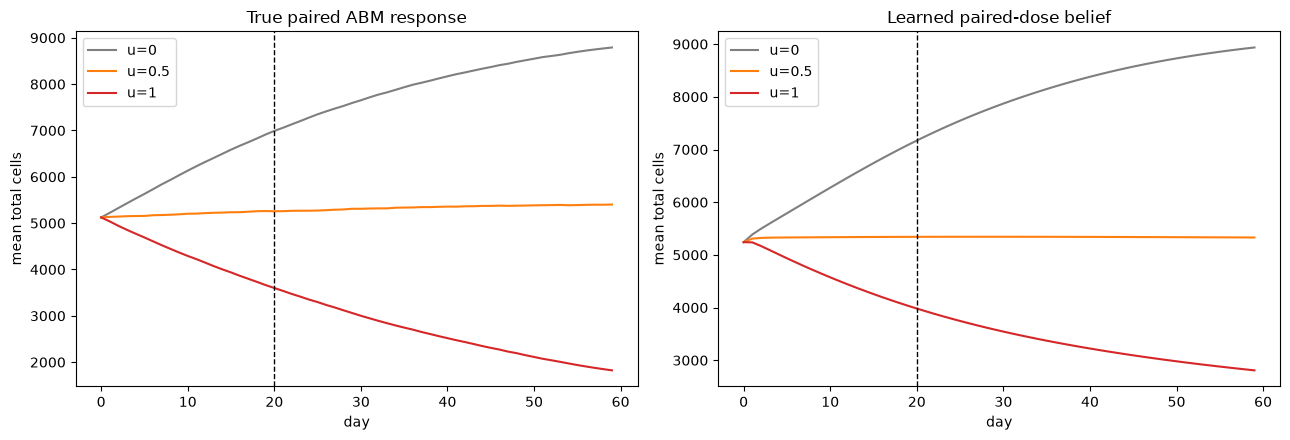

Dose levels:              [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
ABM mean total at H=20:  [6990.4, 5256.8, 3600.3]
JEPA mean total at H=20: [7170.3, 5342.7, 3981.7]
ABM monotone suppression: True
JEPA monotone suppression: True


In [18]:
# Paired fixed-dose test: same initial grid, parameters, and stochastic seed across doses
show = min(60, controlled_enc["z"].shape[1])
controlled_rollout = latent_rollout_batch(
    model,
    controlled_enc["z"][:, 0],
    controlled_enc["controls"][:, :show],
)
controlled_prediction = readout_predict(readout, controlled_rollout)
dose = np.asarray([float(meta["dose_level"]) for meta in controlled_enc["meta"]])
dose_levels = sorted(np.unique(dose))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
colors = {0.0: "tab:gray", 0.5: "tab:orange", 1.0: "tab:red"}
for level in dose_levels:
    mask = dose == level
    true_curve = controlled_enc["obs"][mask, :show, total_obs_idx].mean(axis=0)
    pred_curve = controlled_prediction[mask, :show, total_readout_idx].mean(axis=0)
    axes[0].plot(true_curve, color=colors[level], label=f"u={level:g}")
    axes[1].plot(pred_curve, color=colors[level], label=f"u={level:g}")
for ax, title in zip(axes, ("True paired ABM response", "Learned paired-dose belief"), strict=True):
    ax.axvline(model.hparams.horizon, color="black", ls="--", lw=1)
    ax.set(title=title, xlabel="day", ylabel="mean total cells")
    ax.legend()
fig.tight_layout()
plt.show()

horizon = int(model.hparams.horizon)
true_h = []
pred_h = []
for level in dose_levels:
    mask = dose == level
    true_h.append(float(controlled_enc["obs"][mask, horizon, total_obs_idx].mean()))
    pred_h.append(float(controlled_prediction[mask, horizon, total_readout_idx].mean()))
print("Dose levels:             ", dose_levels)
print("ABM mean total at H=20: ", [round(value, 1) for value in true_h])
print("JEPA mean total at H=20:", [round(value, 1) for value in pred_h])
print("ABM monotone suppression:", bool(np.all(np.diff(true_h) <= 0)))
print("JEPA monotone suppression:", bool(np.all(np.diff(pred_h) <= 0)))

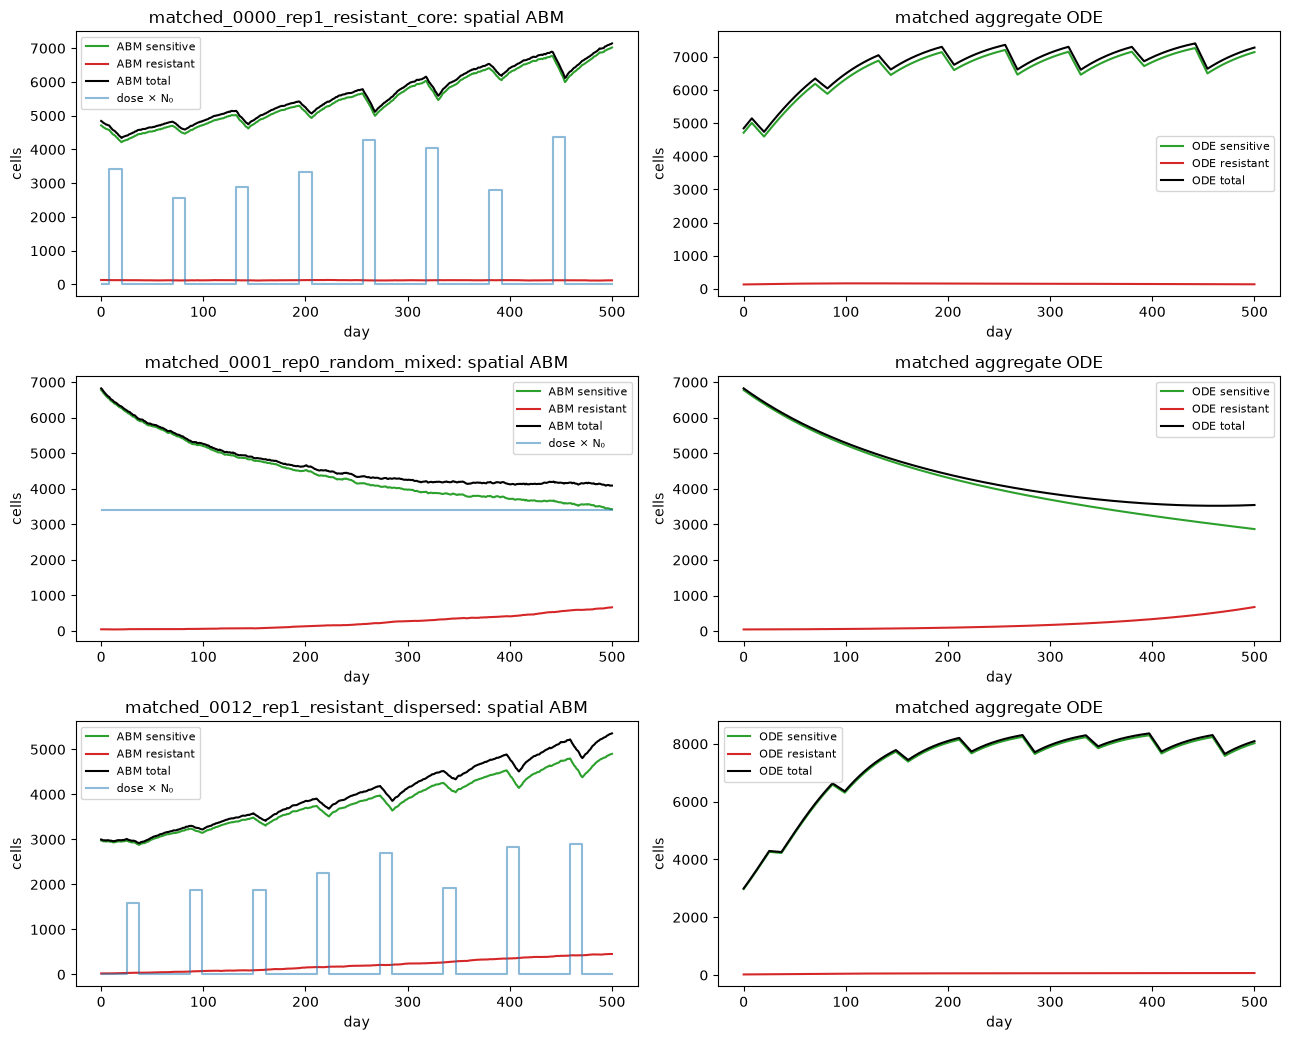

In [19]:
# Matched non-spatial ODE baseline: same initial counts, parameters, and dose schedule
example_ids = [trajectory["run_id"] for trajectory in selected[:3]]
fig, axes = plt.subplots(len(example_ids), 2, figsize=(13, 3.5 * len(example_ids)), squeeze=False)
with h5py.File(DATASET, "r") as h5:
    for row, episode_id in enumerate(example_ids):
        group = h5["episodes"][episode_id]
        abm = np.asarray(group["counts"])
        ode = np.asarray(group["ode_counts"])
        action = np.asarray(group["action"])
        axes[row, 0].plot(abm[:, 0], label="ABM sensitive", color="tab:green")
        axes[row, 0].plot(abm[:, 1], label="ABM resistant", color="tab:red")
        axes[row, 0].plot(abm[:, 2], label="ABM total", color="black")
        axes[row, 0].step(np.arange(len(action)) + 1, action * abm[0, 2], label="dose × N₀", alpha=0.5)
        axes[row, 0].set(title=f"{episode_id}: spatial ABM", xlabel="day", ylabel="cells")
        axes[row, 1].plot(ode[:, 0], label="ODE sensitive", color="tab:green")
        axes[row, 1].plot(ode[:, 1], label="ODE resistant", color="tab:red")
        axes[row, 1].plot(ode[:, 2], label="ODE total", color="black")
        axes[row, 1].set(title="matched aggregate ODE", xlabel="day", ylabel="cells")
        axes[row, 0].legend(fontsize=8)
        axes[row, 1].legend(fontsize=8)
fig.tight_layout()
plt.show()

In [20]:
# Compact diagnostic summary
h = int(model.hparams.horizon)
summary = {
    "best_validation_loss": result["best_val_loss"],
    "test_loss": result["test_metrics"]["test_loss"],
    "latent_participation_ratio": pca["participation_ratio"],
    "total_count_readout_r2": macro_r2["total_count"],
    "resistant_count_readout_r2": macro_r2["resistant_count"],
    "applied_dose_probe_r2": float(u_r2),
    "latent_skill_at_training_horizon": float(errors["skill_full"][h]),
    "paired_abm_dose_monotone_at_horizon": bool(np.all(np.diff(true_h) <= 0)),
    "paired_jepa_dose_monotone_at_horizon": bool(np.all(np.diff(pred_h) <= 0)),
}
print(json.dumps(summary, indent=2))

checks = {
    "latent uses more than one effective dimension": pca["participation_ratio"] > 2,
    "total burden is linearly readable": macro_r2["total_count"] > 0.7,
    "resistant burden is linearly readable": macro_r2["resistant_count"] > 0.5,
    "control signature is retained": u_r2 > 0.2,
    "free rollout beats latent persistence at H=20": errors["full"][h] < errors["persistence"][h],
    "learned dose direction matches suppression": np.all(np.diff(pred_h) <= 0),
}
for name, passed in checks.items():
    print(f"{'PASS' if passed else 'CHECK':>5} — {name}")

{
  "best_validation_loss": 0.28167709708213806,
  "test_loss": 0.5626630783081055,
  "latent_participation_ratio": 4.347972869873047,
  "total_count_readout_r2": 0.9787386429814071,
  "resistant_count_readout_r2": -0.049249530480696135,
  "applied_dose_probe_r2": 0.15478488495001552,
  "latent_skill_at_training_horizon": 0.8980628848075867,
  "paired_abm_dose_monotone_at_horizon": true,
  "paired_jepa_dose_monotone_at_horizon": true
}
 PASS — latent uses more than one effective dimension
 PASS — total burden is linearly readable
CHECK — resistant burden is linearly readable
CHECK — control signature is retained
 PASS — free rollout beats latent persistence at H=20
 PASS — learned dose direction matches suppression


## Closed-loop MPC: JEPA versus matched ODE

Both controllers receive the same current ABM observation at each replanning time and optimize the same finite-horizon objective:

\[
J = \sum_k \left[q_N\,N_k/K + q_R\,R_k/K + q_u u_k^2 + q_{\Delta u}(u_k-u_{k-1})^2\right] + q_f N_H/K.
\]

- **JEPA MPC** encodes the current categorical grid and rolls candidate doses through the learned latent predictor and total-count readout.
- **ODE MPC** starts its matched non-spatial ODE from the currently observed aggregate sensitive/resistant counts.
- Both apply only the first block of each plan to an independently reset but identically seeded Java ABM.
- Resistant burden is not directly weighted by default because its held-out readout is weak; it is still reported in every trajectory.

In [21]:
from jepa_control.strobl_control import (
    StroblMPCConfig,
    StroblPlantConfig,
    compare_strobl_controllers,
)

MPC = StroblMPCConfig(
    plan_horizon=20,
    n_samples=256,
    n_iters=4,
    tumour_weight=1.0,
    resistant_weight=0.0,  # weak resistant-count readout: report, but do not optimize it yet
    control_cost=0.05,
    slew_cost=0.02,
    terminal_weight=1.0,
    seed=7,
)
PLANT = StroblPlantConfig(
    architecture="resistant_edge",
    sensitive=4_900,
    resistant=100,
    seed=17,
    ic_seed=23,
)

mpc_results = compare_strobl_controllers(
    model,
    readout,
    plant=PLANT,
    steps=160,
    mpc=MPC,
    replan_interval=5,
    include_baselines=True,
)

for name, outcome in mpc_results.items():
    print(
        f"{name:>25}: final [S,R,N]={outcome['final_counts'].tolist()}, "
        f"dose={outcome['cumulative_dose']:.1f}, cost={outcome['total_cost']:.3f}"
    )

                 jepa_mpc: final [S,R,N]=[5735, 186, 5921], dose=31.0, cost=87.171
                  ode_mpc: final [S,R,N]=[4185, 227, 4412], dose=154.0, cost=83.352
             no_treatment: final [S,R,N]=[6117, 218, 6335], dose=0.0, cost=90.094
   maximum_tolerated_dose: final [S,R,N]=[4186, 224, 4410], dose=160.0, cost=83.609
           paper_adaptive: final [S,R,N]=[4186, 224, 4410], dose=160.0, cost=83.609


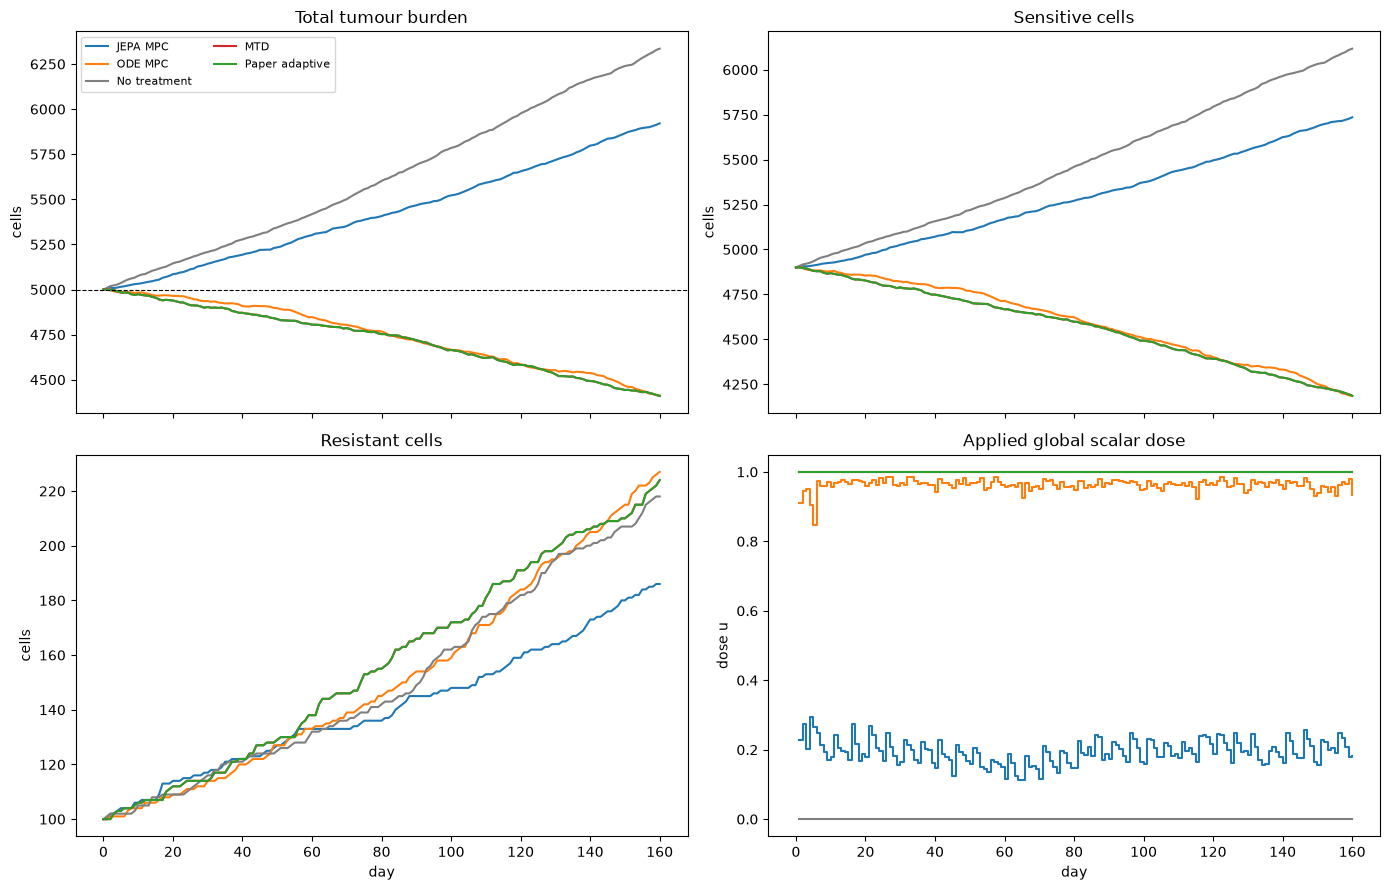

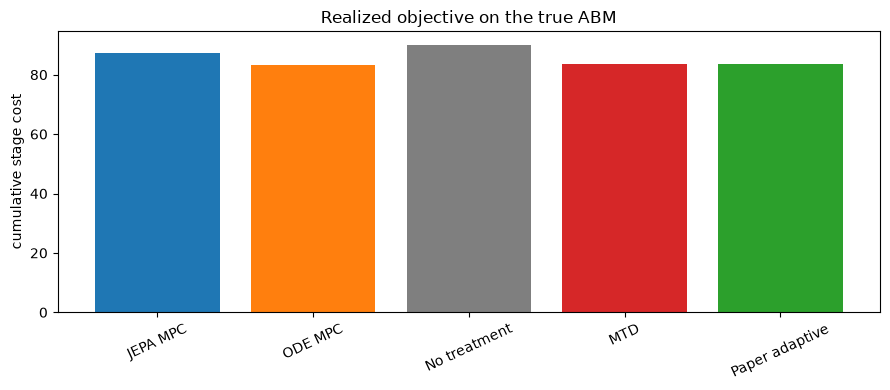

In [22]:
# Closed-loop trajectories under the true spatial ABM
palette = {
    "jepa_mpc": "tab:blue",
    "ode_mpc": "tab:orange",
    "no_treatment": "tab:gray",
    "maximum_tolerated_dose": "tab:red",
    "paper_adaptive": "tab:green",
}
labels = {
    "jepa_mpc": "JEPA MPC",
    "ode_mpc": "ODE MPC",
    "no_treatment": "No treatment",
    "maximum_tolerated_dose": "MTD",
    "paper_adaptive": "Paper adaptive",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for name, outcome in mpc_results.items():
    color = palette[name]
    axes[0, 0].plot(outcome["counts"][:, 2], color=color, label=labels[name])
    axes[0, 1].plot(outcome["counts"][:, 0], color=color, label=labels[name])
    axes[1, 0].plot(outcome["counts"][:, 1], color=color, label=labels[name])
    axes[1, 1].step(np.arange(len(outcome["action"])) + 1, outcome["action"], where="post", color=color, label=labels[name])
axes[0, 0].set(title="Total tumour burden", ylabel="cells")
axes[0, 1].set(title="Sensitive cells", ylabel="cells")
axes[1, 0].set(title="Resistant cells", xlabel="day", ylabel="cells")
axes[1, 1].set(title="Applied global scalar dose", xlabel="day", ylabel="dose u")
axes[0, 0].axhline(PLANT.initial_counts[2], color="black", ls="--", lw=0.8)
axes[0, 0].legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
names = list(mpc_results)
costs = [mpc_results[name]["total_cost"] for name in names]
ax.bar([labels[name] for name in names], costs, color=[palette[name] for name in names])
ax.set(title="Realized objective on the true ABM", ylabel="cumulative stage cost")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

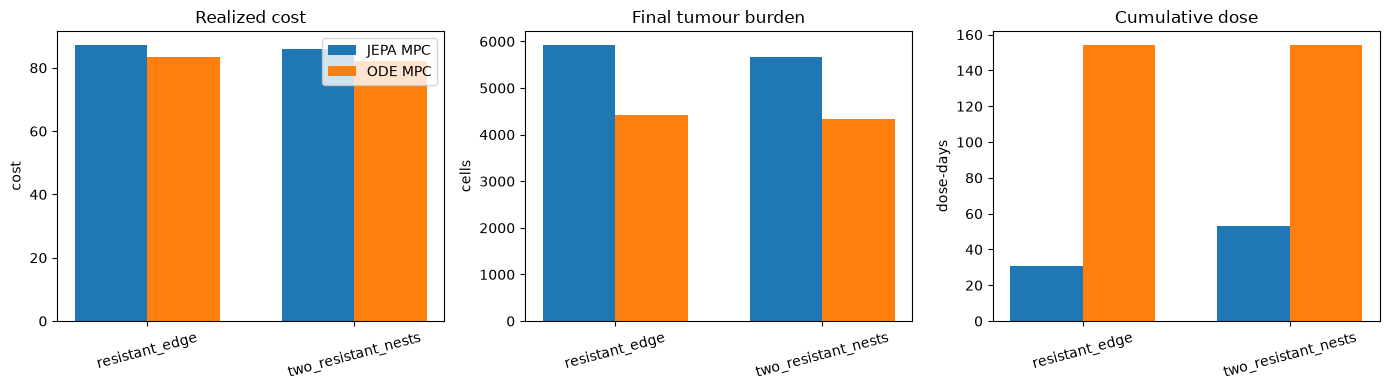

In [23]:
# Architecture sensitivity: reuse the edge case and add the other held-out family.
# Set this flag to False when only the primary comparison is needed.
from dataclasses import replace

RUN_ARCHITECTURE_SWEEP = True
architecture_results = {
    "resistant_edge": {
        "jepa_mpc": mpc_results["jepa_mpc"],
        "ode_mpc": mpc_results["ode_mpc"],
    }
}
if RUN_ARCHITECTURE_SWEEP:
    nests = compare_strobl_controllers(
        model,
        readout,
        plant=replace(PLANT, architecture="two_resistant_nests"),
        steps=160,
        mpc=MPC,
        replan_interval=5,
        include_baselines=False,
    )
    architecture_results["two_resistant_nests"] = nests

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    architectures = list(architecture_results)
    x = np.arange(len(architectures))
    width = 0.35
    for offset, controller in ((-width / 2, "jepa_mpc"), (width / 2, "ode_mpc")):
        values = [architecture_results[a][controller] for a in architectures]
        axes[0].bar(x + offset, [v["total_cost"] for v in values], width, label=labels[controller])
        axes[1].bar(x + offset, [v["final_counts"][2] for v in values], width)
        axes[2].bar(x + offset, [v["cumulative_dose"] for v in values], width)
    for ax, title, ylabel in zip(
        axes,
        ("Realized cost", "Final tumour burden", "Cumulative dose"),
        ("cost", "cells", "dose-days"),
        strict=True,
    ):
        ax.set_xticks(x, architectures, rotation=15)
        ax.set(title=title, ylabel=ylabel)
    axes[0].legend()
    fig.tight_layout()
    plt.show()

## How to interpret the notebook

- **Training curves:** validation loss should decline while participation ratio rises above one. A low predictive loss with participation ratio near one indicates an uninformative collapsed latent.
- **Readout R²:** total, sensitive, and resistant counts should remain readable on held-out architectures. Resistant count is usually the hardest target because it is initially rare.
- **Rollout skill:** the relevant comparison is JEPA versus persistence, especially at the 20-day training horizon. Long extrapolations beyond that horizon are diagnostic rather than guaranteed.
- **Paired-dose response:** the most important control sanity check is the ordering across `u=0`, `0.5`, and `1`. If the learned ordering disagrees with the ABM, do not use the checkpoint for MPC.
- **MPC comparison:** compare realized cost on the true ABM, not each controller's internal predicted objective. A lower dose is not inherently better if burden rises, and a lower burden is not inherently better if it requires disproportionate dose.
- **Architecture sensitivity:** JEPA has access to resistant-cell arrangement; the ODE sees only aggregate counts. Differences that change with architecture are therefore central to the comparison.
- **ABM versus ODE:** disagreement is expected and is part of the benchmark—the ODE cannot represent resistant-cell arrangement or local competition.

These diagnostics assess a synthetic control benchmark. They do not establish biological or clinical validity.